In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = load_digits()

X = data.data
y = data.target

print("Dataset shape:", X.shape)

Dataset shape: (1797, 64)


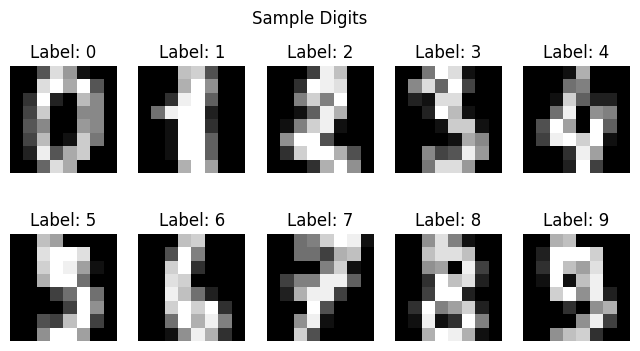

In [3]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(data.images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.suptitle("Sample Digits")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9444444444444444


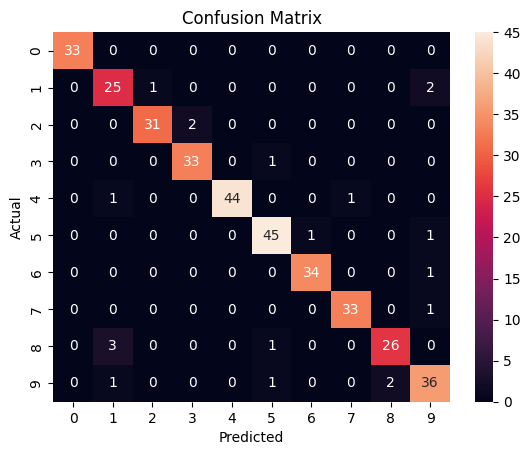

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.83      0.89      0.86        28
           2       0.97      0.94      0.95        33
           3       0.94      0.97      0.96        34
           4       1.00      0.96      0.98        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.93      0.87      0.90        30
           9       0.88      0.90      0.89        40

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360



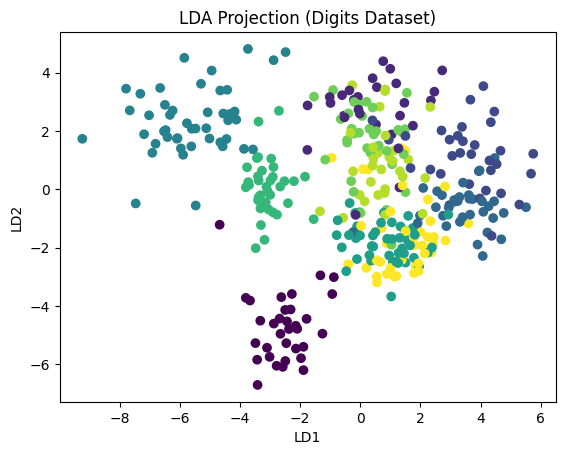

In [10]:
X_lda = lda.transform(X_test)

plt.figure()
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_test)
plt.title("LDA Projection (Digits Dataset)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()